# Projektni zadatak iz Ekonometrije

Prezime i ime: Petar  Belko \
Matični broj: 0066299238  
Akademska godina 2025./2026. \
Kategorija izdataka: GASO \
Period analize: 

In [2]:
# Import necessary libraries
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Učitavanje podataka
data_path = 'demand.xlsx'
df = pd.read_excel(data_path)

# Čišćenje podataka - zadržavamo samo potrebne stupce
cols_to_keep = ['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']
df = df[cols_to_keep]

print("=== Stupci nakon čišćenja ===")
print(df.columns.tolist())
print("\nPrvih 5 redova:")
print(df.head())

=== Stupci nakon čišćenja ===
['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']

Prvih 5 redova:
        gaso   pgaso     dpi    ptpe     pop  time
0  60.744761  18.576  1715.5  20.432  177130     1
1  62.825049  19.112  1759.7  20.767  180760     2
2  63.473382  18.924  1819.2  20.985  183742     3
3  66.165106  19.043  1908.2  21.232  186590     4
4  68.197955  18.997  1979.1  21.479  189300     5


### Kreiranje Indeksa relativnih cijena

In [3]:
# Kreiranje Indeksa relativnih cijena
df['prgaso'] = 100 * (df['pgaso'] / df['ptpe'])
print("\nPrvih 5 redova:")
print(df.head(5)[['prgaso']])


Prvih 5 redova:
      prgaso
0  90.916210
1  92.030626
2  90.178699
3  89.690090
4  88.444527


### Osnovni deskriptivni pokazatelji dodijeljene kategorije (GASO)

=== Deskriptivni pokazatelji za GASO ===

1. Aritmetička sredina: 122.0260
   → Prosječna potrošnja benzina iznosi 122.0260 jedinica.

2. Medijan: 120.6637
   → Polovica promatranja ima potrošnju manju od 120.6637 jedinica.

3. Asimetrija (α₃): -0.0791
   → Distribucija je negativno asimetrična (rep je s lijeve strane).

4. Spljoštenost (α₄): -0.8297
   → Distribucija je plosnatija od normalne.

5. Standardna devijacija: 35.1763
   → Potrošnja benzina u prosjeku odstupa 35.1763 jedinica od aritmetičke sredine.


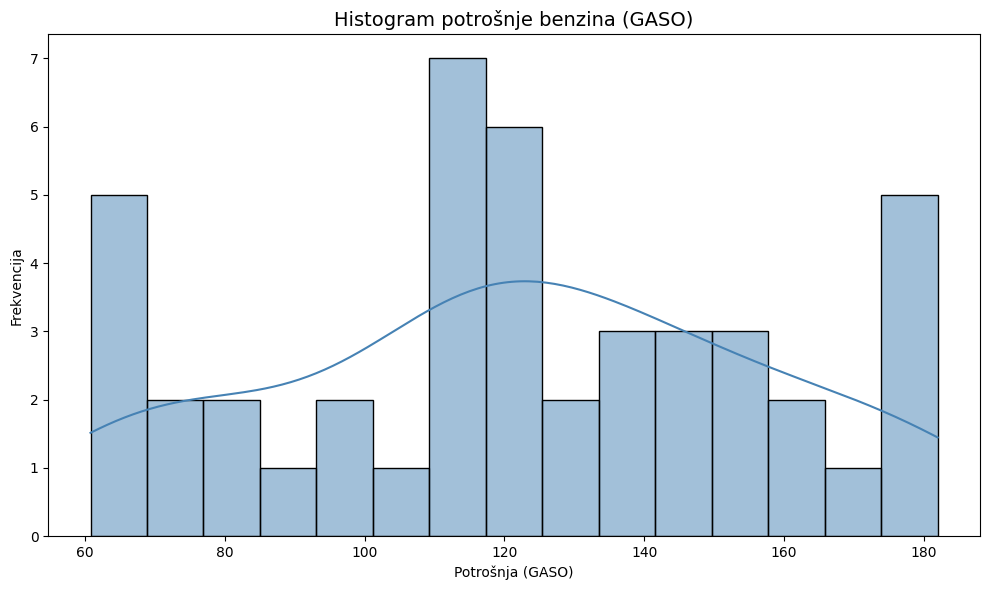

In [4]:
# Deskriptivni pokazatelji za GASO
print("=== Deskriptivni pokazatelji za GASO ===\n")

mean = df['gaso'].mean()
median = df['gaso'].median()
std = df['gaso'].std()
skew = df['gaso'].skew()
kurt = df['gaso'].kurtosis()

print(f"1. Aritmetička sredina: {mean:.4f}")
print(f"   → Prosječna potrošnja benzina iznosi {mean:.4f} jedinica.\n")

print(f"2. Medijan: {median:.4f}")
print(f"   → Polovica promatranja ima potrošnju manju od {median:.4f} jedinica.\n")

print(f"3. Asimetrija (α₃): {skew:.4f}")
if skew > 0:
    print(f"   → Distribucija je pozitivno asimetrična (rep je s desne strane).\n")
elif skew < 0:
    print(f"   → Distribucija je negativno asimetrična (rep je s lijeve strane).\n")
else:
    print(f"   → Distribucija je simetrična.\n")

print(f"4. Spljoštenost (α₄): {kurt:.4f}")
if kurt > 0:
    print(f"   → Distribucija je šiljatija od normalne.\n")
elif kurt < 0:
    print(f"   → Distribucija je plosnatija od normalne.\n")
else:
    print(f"   → Distribucija ima normalnu spljoštenost.\n")

print(f"5. Standardna devijacija: {std:.4f}")
print(f"   → Potrošnja benzina u prosjeku odstupa {std:.4f} jedinica od aritmetičke sredine.")

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['gaso'], kde=True, color='steelblue', bins=15)
plt.title('Histogram potrošnje benzina (GASO)', fontsize=14)
plt.xlabel('Potrošnja (GASO)')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.show()

### Višestruka linearna regresija

In [5]:
# Kreiranje log varijabli
df['log_gaso'] = np.log(df['gaso'])
df['log_dpi'] = np.log(df['dpi'])
df['log_prgaso'] = np.log(df['prgaso'])

# Definiranje zavisne i nezavisnih varijabli
y = df['log_gaso']
X = df[['log_dpi', 'log_prgaso']]
X = sm.add_constant(X)

# Procjena modela
model = sm.OLS(y, X).fit()
print(model.summary())

# ============================================================
# PROCIJENJENA REGRESIJSKA JEDNADŽBA
# ============================================================
b0 = model.params['const']
b1 = model.params['log_dpi']
b2 = model.params['log_prgaso']

print("\n=== Procijenjena regresijska jednadžba ===")
print(f"log(GASO) = {b0:.4f} + {b1:.4f}*log(DPI) + {b2:.4f}*log(PRGASO)")

print("\n=== Interpretacija koeficijenta uz log(PRGASO) ===")
print(f"Koeficijent uz log(PRGASO) iznosi {b2:.4f}.")
print(f"To znači da, uz ostale varijable nepromijenjene, povećanje relativne")
print(f"cijene benzina za 1% dovodi do prosječnog smanjenja potrošnje benzina za {b2:.4f}%.")
print(f"Radi se o elastičnosti potražnje s obzirom na relativnu cijenu.")

# ============================================================
# SKUPNI TEST (F-test)
# ============================================================
print("\n=== Skupni F-test ===")
print("H₀: β₁ = β₂ = 0  (model nije statistički značajan)")
print("H₁: barem jedan βᵢ ≠ 0  (model je statistički značajan)")
print(f"\nF-statistika: {model.fvalue:.4f}")
print(f"p-vrijednost: {model.f_pvalue:.4f}")
if model.f_pvalue < 0.05:
    print("→ Odbacujemo H₀. Model je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. Model nije statistički značajan na razini 5%.")

# ============================================================
# POJEDINAČNI JEDNOSMJERNI TESTOVI (t-testovi)
# ============================================================
print("\n=== Pojedinačni jednosmjerni t-testovi ===")

# Test za log(DPI)
print("\n--- Test za log(DPI) ---")
print("H₀: β₁ = 0")
print("H₁: β₁ > 0  (veći dohodak → veća potrošnja benzina)")
t_dpi = model.tvalues['log_dpi']
p_dpi = model.pvalues['log_dpi'] / 2  # jednosmjerni test
print(f"t-statistika: {t_dpi:.4f}")
print(f"p-vrijednost (jednosmjerni): {p_dpi:.4f}")
if p_dpi < 0.05:
    print("→ Odbacujemo H₀. log(DPI) je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. log(DPI) nije statistički značajan na razini 5%.")

# Test za log(PRGASO)
print("\n--- Test za log(PRGASO) ---")
print("H₀: β₂ = 0")
print("H₁: β₂ < 0  (viša relativna cijena → manja potrošnja benzina)")
t_prgaso = model.tvalues['log_prgaso']
p_prgaso = model.pvalues['log_prgaso'] / 2  # jednosmjerni test
print(f"t-statistika: {t_prgaso:.4f}")
print(f"p-vrijednost (jednosmjerni): {p_prgaso:.4f}")
if p_prgaso < 0.05:
    print("→ Odbacujemo H₀. log(PRGASO) je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. log(PRGASO) nije statistički značajan na razini 5%.")

                            OLS Regression Results                            
Dep. Variable:               log_gaso   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     730.4
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.36e-33
Time:                        13:40:33   Log-Likelihood:                 69.130
No. Observations:                  45   AIC:                            -132.3
Df Residuals:                      42   BIC:                            -126.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8568      0.281     -3.051      0.0

### Analiza reziduala iz modela višestruke regresije

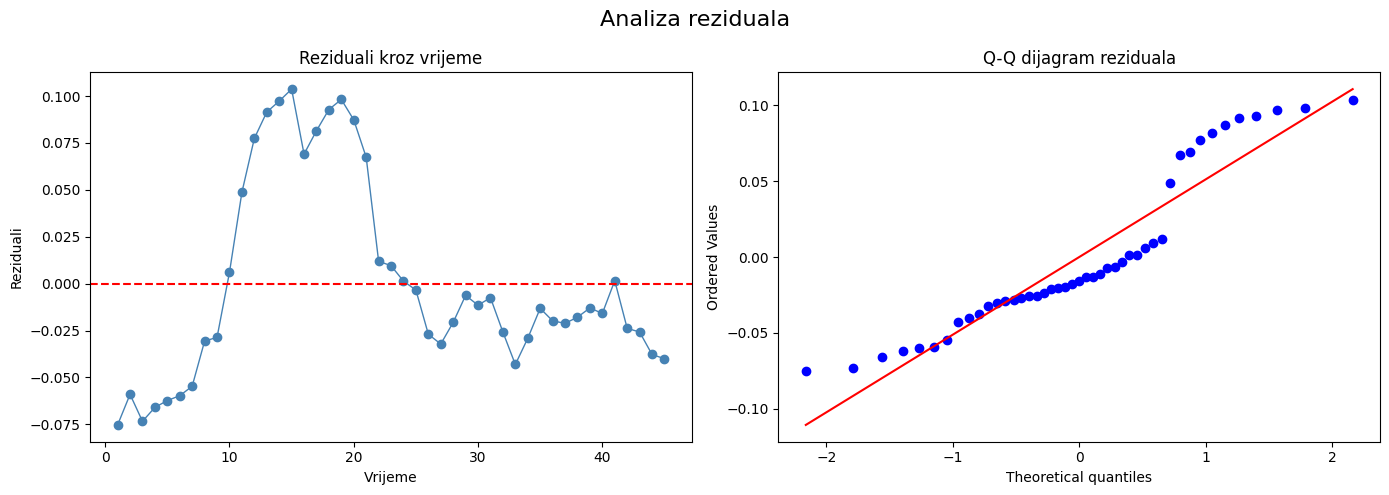


=== Test normalnosti (Jarque-Bera) ===
H₀: Reziduali su normalno distribuirani
H₁: Reziduali nisu normalno distribuirani

JB-statistika: 4.7863
p-vrijednost: 0.0913
→ Ne odbacujemo H₀. Reziduali su normalno distribuirani na razini 5%.

=== Analiza stacionarnosti reziduala ===
Srednja vrijednost reziduala: -0.000000
Standardna devijacija reziduala: 0.0527
→ Srednja vrijednost reziduala je bliska nuli — uvjet nepristranosti je zadovoljen.

=== Interpretacija grafičke analize ===
1. Graf reziduala kroz vrijeme:
   → Reziduali NISU stacionarni.
   → Vidljiv je trend — reziduali su negativni na početku,
   → rastu do vrha oko t=15, pa padaju i ostaju negativni.
   → Ovo ukazuje na autokorelaciju reziduala — pretpostavka o međusobnoj
   → nezavisnosti reziduala NIJE zadovoljena.

2. Q-Q dijagram:
   → U centralnom dijelu točke relativno dobro prate pravac.
   → Na lijevom repu točke su ispod pravca → tanji lijevi rep od normalne.
   → Na desnom repu točke su iznad pravca → deblji desni rep 

In [6]:
# Dohvaćanje reziduala
residuals = model.resid
fitted = model.fittedvalues

# ============================================================
# 1. GRAFIČKA ANALIZA REZIDUALA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analiza reziduala', fontsize=16)

# 1.1 Reziduali kroz vrijeme
axes[0].plot(df['time'], residuals, marker='o', color='steelblue', linewidth=1)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Reziduali kroz vrijeme')
axes[0].set_xlabel('Vrijeme')
axes[0].set_ylabel('Reziduali')

# 1.2 Q-Q dijagram
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q dijagram reziduala')

plt.tight_layout()
plt.show()

# ============================================================
# 2. TEST NORMALNOSTI (Jarque-Bera)
# ============================================================
jb_stat, jb_p = stats.jarque_bera(residuals)
print("\n=== Test normalnosti (Jarque-Bera) ===")
print("H₀: Reziduali su normalno distribuirani")
print("H₁: Reziduali nisu normalno distribuirani")
print(f"\nJB-statistika: {jb_stat:.4f}")
print(f"p-vrijednost: {jb_p:.4f}")
if jb_p < 0.05:
    print("→ Odbacujemo H₀. Reziduali nisu normalno distribuirani na razini 5%.")
    print("→ Posljedica: t i F testovi nisu pouzdani, intervali pouzdanosti mogu biti netočni.")
else:
    print("→ Ne odbacujemo H₀. Reziduali su normalno distribuirani na razini 5%.")

# ============================================================
# 3. STACIONARNOST REZIDUALA
# ============================================================
print("\n=== Analiza stacionarnosti reziduala ===")
print(f"Srednja vrijednost reziduala: {residuals.mean():.6f}")
print(f"Standardna devijacija reziduala: {residuals.std():.4f}")

if abs(residuals.mean()) < 0.001:
    print("→ Srednja vrijednost reziduala je bliska nuli — uvjet nepristranosti je zadovoljen.")
else:
    print("→ Srednja vrijednost reziduala nije bliska nuli — moguć problem s modelom.")

# ============================================================
# 4. INTERPRETACIJA
# ============================================================
print("\n=== Interpretacija grafičke analize ===")

print("1. Graf reziduala kroz vrijeme:")
print("   → Reziduali NISU stacionarni.")
print("   → Vidljiv je trend — reziduali su negativni na početku,")
print("   → rastu do vrha oko t=15, pa padaju i ostaju negativni.")
print("   → Ovo ukazuje na autokorelaciju reziduala — pretpostavka o međusobnoj")
print("   → nezavisnosti reziduala NIJE zadovoljena.")

print("\n2. Q-Q dijagram:")
print("   → U centralnom dijelu točke relativno dobro prate pravac.")
print("   → Na lijevom repu točke su ispod pravca → tanji lijevi rep od normalne.")
print("   → Na desnom repu točke su iznad pravca → deblji desni rep od normalne.")
print("   → Ovo ukazuje na blagu asimetriju distribucije reziduala.")

print("\n3. Zaključak:")
print("   → Jarque-Bera test ne odbacuje normalnost reziduala (p=0.0913 > 0.05)")
print("   → Pretpostavka normalnosti reziduala je zadovoljena.")
print("   → Međutim, graf reziduala kroz vrijeme ukazuje na autokorelaciju,")
print("   → što je ozbiljniji problem koji narušava pouzdanost OLS procjenitelja.")

print("\n4. Posljedice ne-normalnosti i autokorelacije:")
print("   → t i F testovi gube pouzdanost")
print("   → Intervali pouzdanosti mogu biti netočni")
print("   → Procjenitelji OLS ostaju nepristrani, ali nisu najefikasniji")
print("   → Preporučuje se Durbin-Watson test za formalnu provjeru autokorelacije")

### Intervalne procjene parametara

In [7]:

# ============================================================
# INTERVALNA PROCJENA ZA log(PRGASO)
# ============================================================
conf_int = model.conf_int(alpha=0.05)

lb = conf_int.loc['log_prgaso', 0]
ub = conf_int.loc['log_prgaso', 1]

print("=== 95%-tni interval procjene za koeficijent uz log(PRGASO) ===\n")
print(f"Donja granica: {lb:.4f}")
print(f"Gornja granica: {ub:.4f}")
print(f"\nInterval: [{lb:.4f}, {ub:.4f}]")

print("\n=== Interpretacija ===")
print(f"S 95%-tnom pouzdanošću možemo tvrditi da se pravi koeficijent")
print(f"elastičnosti potražnje za benzinom s obzirom na relativnu cijenu")
print(f"nalazi u intervalu [{lb:.4f}, {ub:.4f}].")

contains_zero = lb < 0 < ub
if contains_zero:
    print(f"\nBudući da interval sadrži nulu, koeficijent NIJE statistički")
    print(f"značajan na razini značajnosti od 5%.")
    print(f"\nInterval prelazi nulu (donja granica je negativna, gornja pozitivna),")
    print(f"stoga ne možemo sa 95%-tnom pouzdanošću zaključiti o smjeru utjecaja")
    print(f"relativne cijene benzina na potrošnju.")
else:
    print(f"\nBudući da interval ne sadrži nulu, koeficijent je statistički")
    print(f"značajan na razini značajnosti od 5%.")
    if ub < 0:
        print(f"\nOba ruba intervala su negativna, što potvrđuje očekivani")
        print(f"negativan odnos između relativne cijene i potrošnje benzina —")
        print(f"porast relativne cijene benzina za 1% smanjuje potrošnju")
        print(f"između {abs(ub):.4f}% i {abs(lb):.4f}%.")
    else:
        print(f"\nOba ruba intervala su pozitivna, što upućuje na pozitivan")
        print(f"odnos između relativne cijene i potrošnje benzina —")
        print(f"porast relativne cijene benzina za 1% povećava potrošnju")
        print(f"između {abs(lb):.4f}% i {abs(ub):.4f}%.")


=== 95%-tni interval procjene za koeficijent uz log(PRGASO) ===

Donja granica: -0.1607
Gornja granica: 0.0555

Interval: [-0.1607, 0.0555]

=== Interpretacija ===
S 95%-tnom pouzdanošću možemo tvrditi da se pravi koeficijent
elastičnosti potražnje za benzinom s obzirom na relativnu cijenu
nalazi u intervalu [-0.1607, 0.0555].

Budući da interval sadrži nulu, koeficijent NIJE statistički
značajan na razini značajnosti od 5%.

Interval prelazi nulu (donja granica je negativna, gornja pozitivna),
stoga ne možemo sa 95%-tnom pouzdanošću zaključiti o smjeru utjecaja
relativne cijene benzina na potrošnju.


### Procjene parametara

In [9]:

# ============================================================
# KOJA VARIJABLA VIŠE UTJEČE NA POTROŠNJU BENZINA?
# ============================================================
# Napomena o odabiru modela:
# Koristimo log-log (dvostruko-logaritamski) OLS model jer su sve
# varijable transformirane logaritmom, pa su procijenjeni koeficijenti
# izravno interpretirani kao elastičnosti koje se
# mogu međusobno uspoređivati bez dodatne standardizacije.

b1_abs = abs(model.params['log_dpi'])
b2_abs = abs(model.params['log_prgaso'])

print("=== Usporedba utjecaja varijabli na log(GASO) ===\n")
print(f"Koeficijent uz log(DPI)    (elastičnost dohotka):  {model.params['log_dpi']:.4f}")
print(f"  |β₁| = {b1_abs:.4f}  |  t = {model.tvalues['log_dpi']:.4f}  |  "
      f"p (dvostrani) = {model.pvalues['log_dpi']:.4f}")

print(f"\nKoeficijent uz log(PRGASO) (elastičnost cijene):  {model.params['log_prgaso']:.4f}")
print(f"  |β₂| = {b2_abs:.4f}  |  t = {model.tvalues['log_prgaso']:.4f}  |  "
      f"p (dvostrani) = {model.pvalues['log_prgaso']:.4f}")

print("\n=== Zaključak ===")
print(f"Budući da je model log-log, oba koeficijenta predstavljaju elastičnosti")
print(f"i izravno su usporedivi po apsolutnoj vrijednosti.\n")
print(f"  |β₁(DPI)|    = {b1_abs:.4f}  (statistički značajan, p ≈ 0.000)")
print(f"  |β₂(PRGASO)| = {b2_abs:.4f}  (statistički NEznačajan, p = {model.pvalues['log_prgaso']:.4f})\n")

if b1_abs > b2_abs:
    print("→ Osobni dohodak (DPI) ima VEĆI utjecaj na potrošnju benzina od relativne cijene.")
    print(f"  Porast dohotka za 1% prosječno povećava potrošnju benzina za {b1_abs:.4f}%,")
    print(f"  dok je elastičnost prema relativnoj cijeni ({model.params['log_prgaso']:.4f}) zanemariva")
    print(f"  i statistički nije različita od nule na razini značajnosti od 5%.")
else:
    print("→ Relativna cijena (PRGASO) ima VEĆI utjecaj na potrošnju benzina od osobnog dohotka.")


=== Usporedba utjecaja varijabli na log(GASO) ===

Koeficijent uz log(DPI)    (elastičnost dohotka):  0.7085
  |β₁| = 0.7085  |  t = 38.2065  |  p (dvostrani) = 0.0000

Koeficijent uz log(PRGASO) (elastičnost cijene):  -0.0526
  |β₂| = 0.0526  |  t = -0.9826  |  p (dvostrani) = 0.3314

=== Zaključak ===
Budući da je model log-log, oba koeficijenta predstavljaju elastičnosti
i izravno su usporedivi po apsolutnoj vrijednosti.

  |β₁(DPI)|    = 0.7085  (statistički značajan, p ≈ 0.000)
  |β₂(PRGASO)| = 0.0526  (statistički NEznačajan, p = 0.3314)

→ Osobni dohodak (DPI) ima VEĆI utjecaj na potrošnju benzina od relativne cijene.
  Porast dohotka za 1% prosječno povećava potrošnju benzina za 0.7085%,
  dok je elastičnost prema relativnoj cijeni (-0.0526) zanemariva
  i statistički nije različita od nule na razini značajnosti od 5%.


### Testiranje restrikcija na parametre

In [11]:

import scipy.stats as stats
import numpy as np

# ============================================================
# TESTIRANJE: Je li β₁ = 2·|β₂|  (tj. β₁ + 2·β₂ = 0)?
# ============================================================

# --- 1. FORMULACIJA HIPOTEZE ---
print("=== 1. Formulacija hipoteze ===\n")
print("Model: log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + ε")
print()
print("Budući da su oba koeficijenta elastičnosti (log-log model), pitanje")
print("'je li DPI dvostruko veći utjecaj od PRGASO' formalizira se kao:")
print()
print("  H₀: β₁ = 2·|β₂|")
print("  Kako je β₂ < 0, vrijedi |β₂| = −β₂, pa:")
print("  H₀: β₁ = −2·β₂   ⟺   β₁ + 2·β₂ = 0")
print("  H₁: β₁ + 2·β₂ ≠ 0   (dvostrani test)")
print()
print("  Razina značajnosti: α = 1% = 0.01")

# --- 2. TEST VELIČINA I POSTUPAK ---
print("\n=== 2. Test veličina i postupak testiranja ===\n")
print()
print("Test veličina:")
print("            β̂₁ + 2·β̂₂")
print("  t = ─────────────────────────────────────────────────")
print("      √[Var(β̂₁) + 4·Var(β̂₂) + 4·Cov(β̂₁, β̂₂)]")
print()
print("Pod H₀, t ~ t(n − k − 1) = t(42).")
print()
print("Odbacujemo H₀ ako |t| > t_{α/2, 42}  (dvostrana kritična vrijednost).")

# --- 3. IZRAČUN RUČNO ---
print("\n=== 3. Ručni izračun test veličine ===\n")

b1_hat = model.params['log_dpi']
b2_hat = model.params['log_prgaso']
cov_matrix = model.cov_params()

var_b1 = cov_matrix.loc['log_dpi', 'log_dpi']
var_b2 = cov_matrix.loc['log_prgaso', 'log_prgaso']
cov_b1_b2 = cov_matrix.loc['log_dpi', 'log_prgaso']

linear_combo = b1_hat + 2 * b2_hat
se_combo = np.sqrt(var_b1 + 4 * var_b2 + 4 * cov_b1_b2)
t_stat = linear_combo / se_combo
df_resid = int(model.df_resid)

print(f"  β̂₁                      = {b1_hat:.6f}")
print(f"  β̂₂                      = {b2_hat:.6f}")
print(f"  β̂₁ + 2·β̂₂              = {linear_combo:.6f}")
print(f"  Var(β̂₁)                 = {var_b1:.8f}")
print(f"  Var(β̂₂)                 = {var_b2:.8f}")
print(f"  Cov(β̂₁, β̂₂)            = {cov_b1_b2:.8f}")
print(f"  SE(β̂₁ + 2·β̂₂)          = {se_combo:.6f}")
print(f"  t-statistika             = {t_stat:.4f}")

# --- 4. PROVJERA PUTEM statsmodels t_test ---
print("\n=== 4. Provjera – statsmodels t_test ===\n")
# R vektor: 0·const + 1·log_dpi + 2·log_prgaso = 0
restriction = "log_dpi + 2*log_prgaso = 0"
t_test_result = model.t_test(restriction)
print(t_test_result)

# --- 5. KRITIČNA VRIJEDNOST I ODLUKA ---
print("\n=== 5. Kritična vrijednost i odluka ===\n")
alpha = 0.01
t_crit = stats.t.ppf(1 - alpha / 2, df=df_resid)
p_value = float(t_test_result.pvalue)

print(f"  Razina značajnosti α = {alpha} (1%)")
print(f"  Stupnjevi slobode    = {df_resid}")
print(f"  Kritična vrijednost  t_{{0.005, {df_resid}}} = ±{t_crit:.4f}")
print(f"  |t-statistika|       = {abs(t_stat):.4f}")
print(f"  p-vrijednost (dvostrana) = {p_value:.4f}")
print()
if abs(t_stat) > t_crit:
    print(f"  |{abs(t_stat):.4f}| > {t_crit:.4f}  →  ODBACUJEMO H₀")
else:
    print(f"  |{abs(t_stat):.4f}| ≤ {t_crit:.4f}  →  NE ODBACUJEMO H₀")

# --- 6. INTERPRETACIJA ---
print("\n=== 6. Interpretacija zaključka ===\n")
if abs(t_stat) > t_crit:
    print("Na razini značajnosti od 1%, odbacujemo hipotezu da je elastičnost")
    print("potražnje za benzinom s obzirom na dohodak dvostruko veća (po")
    print("apsolutnoj vrijednosti) od elastičnosti s obzirom na relativnu cijenu.")
    print(f"Procijenjene elastičnosti (β̂₁ = {b1_hat:.4f}, β̂₂ = {b2_hat:.4f})")
    print("statistički se značajno razlikuju od odnosa 2:1.")
else:
    print("Na razini značajnosti od 1%, ne odbacujemo hipotezu da je elastičnost")
    print("potražnje za benzinom s obzirom na dohodak dvostruko veća (po")
    print("apsolutnoj vrijednosti) od elastičnosti s obzirom na relativnu cijenu.")
    print(f"Podatci su konzistentni s ograničenjem β₁ + 2·β₂ = 0")
    print(f"(β̂₁ = {b1_hat:.4f}, β̂₂ = {b2_hat:.4f}).")


=== 1. Formulacija hipoteze ===

Model: log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + ε

Budući da su oba koeficijenta elastičnosti (log-log model), pitanje
'je li DPI dvostruko veći utjecaj od PRGASO' formalizira se kao:

  H₀: β₁ = 2·|β₂|
  Kako je β₂ < 0, vrijedi |β₂| = −β₂, pa:
  H₀: β₁ = −2·β₂   ⟺   β₁ + 2·β₂ = 0
  H₁: β₁ + 2·β₂ ≠ 0   (dvostrani test)

  Razina značajnosti: α = 1% = 0.01

=== 2. Test veličina i postupak testiranja ===


Test veličina:
            β̂₁ + 2·β̂₂
  t = ─────────────────────────────────────────────────
      √[Var(β̂₁) + 4·Var(β̂₂) + 4·Cov(β̂₁, β̂₂)]

Pod H₀, t ~ t(n − k − 1) = t(42).

Odbacujemo H₀ ako |t| > t_{α/2, 42}  (dvostrana kritična vrijednost).

=== 3. Ručni izračun test veličine ===

  β̂₁                      = 0.708460
  β̂₂                      = -0.052638
  β̂₁ + 2·β̂₂              = 0.603183
  Var(β̂₁)                 = 0.00034384
  Var(β̂₂)                 = 0.00286971
  Cov(β̂₁, β̂₂)            = -0.00005223
  SE(β̂₁ + 2·β̂₂)        

### Multikolinearnost

In [15]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# PRIPREMA VARIJABLI
# ============================================================
df['log_gaso']   = np.log(df['gaso'])
df['log_dpi']    = np.log(df['dpi'])
df['log_prgaso'] = np.log(df['prgaso'])
# TIME je već u df['time'] kao 1..n

# ============================================================
# KORELACIJSKA MATRICA: TIME, log(DPI), log(PRGASO)
# ============================================================
print("=" * 65)
print("1. KORELACIJSKA MATRICA: TIME, log(DPI), log(PRGASO)")
print("=" * 65)

corr_vars = df[['time', 'log_dpi', 'log_prgaso']]
corr_matrix = corr_vars.corr()
print(corr_matrix.to_string())

# ============================================================
# REGRESIJA S TRENDOM: log(GASO) ~ log(DPI) + log(PRGASO) + TIME
# ============================================================
print("\n" + "=" * 65)
print("2. REGRESIJA S TRENDOM")
print("   log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + β₃·TIME + ε")
print("=" * 65)

y_t   = df['log_gaso']
X_t   = sm.add_constant(df[['log_dpi', 'log_prgaso', 'time']])
model_t = sm.OLS(y_t, X_t).fit()
print(model_t.summary())

# ============================================================
# INTERPRETACIJA KOEFICIJENTA UZ TIME
# ============================================================
b3 = model_t.params['time']
print("\n=== Interpretacija koeficijenta uz TIME ===\n")
print(f"Koeficijent uz TIME (β̂₃) = {b3:.6f}")
print(f"Porast vremena za jednu vremensku jedinicu (1 kvartal), uz nepromijenjene")
print(f"ostale varijable, mijenja potrošnju benzina prosječno za ≈ {b3 * 100:.4f}%.")
if b3 > 0:
    print(f"Trend je POZITIVAN: potrošnja benzina raste s vremenom.")
else:
    print(f"Trend je NEGATIVAN: potrošnja benzina pada s vremenom.")

# ============================================================
# JEDNOSMJERNI T-TEST ZA TIME (H₁: β₃ < 0)
# ============================================================
print("\n=== Jednosmjerni t-test za TIME ===")
print("H₀: β₃ = 0")
print("H₁: β₃ < 0  (negativan vremenski trend potrošnje benzina)")
t_time   = model_t.tvalues['time']
p_time_2 = model_t.pvalues['time']
# Jednosmjerni p za H₁: β₃ < 0 — t je negativan, p = p_dvostrani / 2
p_time_1 = p_time_2 / 2 if t_time < 0 else 1 - p_time_2 / 2
df_t     = int(model_t.df_resid)
t_crit_5 = stats.t.ppf(0.95, df=df_t)  # negativna kritična vrijednost: -t_crit_5
print(f"t-statistika: {t_time:.4f}")
print(f"p-vrijednost (jednosmjerni): {p_time_1:.4f}")
print(f"Kritična vrijednost −t_{{0.05, {df_t}}} = −{t_crit_5:.4f}")
if p_time_1 < 0.05:
    print("→ Odbacujemo H₀. TIME je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. TIME nije statistički značajan na razini 5%.")

# ============================================================
# USPOREDBA MODELA: s TIME vs. bez TIME (Zadatak 1)
# ============================================================
print("\n" + "=" * 65)
print("3. USPOREDBA: MODEL BEZ TIME (Zadatak 1) vs. MODEL S TIME")
print("=" * 65)

y0 = df['log_gaso']
X0 = sm.add_constant(df[['log_dpi', 'log_prgaso']])
model0 = sm.OLS(y0, X0).fit()

header = f"{'Veličina':<30} {'Bez TIME':>12} {'S TIME':>12}"
print(header)
print("-" * len(header))
print(f"{'R²':<30} {model0.rsquared:>12.4f} {model_t.rsquared:>12.4f}")
print(f"{'Adj. R²':<30} {model0.rsquared_adj:>12.4f} {model_t.rsquared_adj:>12.4f}")
print(f"{'AIC':<30} {model0.aic:>12.4f} {model_t.aic:>12.4f}")
print(f"{'β̂(log_dpi)':<30} {model0.params['log_dpi']:>12.4f} {model_t.params['log_dpi']:>12.4f}")
print(f"{'SE(log_dpi)':<30} {model0.bse['log_dpi']:>12.4f} {model_t.bse['log_dpi']:>12.4f}")
print(f"{'β̂(log_prgaso)':<30} {model0.params['log_prgaso']:>12.4f} {model_t.params['log_prgaso']:>12.4f}")
print(f"{'SE(log_prgaso)':<30} {model0.bse['log_prgaso']:>12.4f} {model_t.bse['log_prgaso']:>12.4f}")
print()
print("Ako dodavanje TIME-a značajno povećava SE koeficijenata → sign multikolinearnosti.")

# ============================================================
# 4. KLEINOV KRITERIJ
# ============================================================
print("\n" + "=" * 65)
print("4. KLEINOV KRITERIJ MULTIKOLINEARNOSTI")
print("=" * 65)
print("Kriterij: multikolinearnost je problematična ako je r(xᵢ,xⱼ)²")
print("veći od R² punog modela (s TIME).\n")

R2_full = model_t.rsquared
print(f"R² punog modela (s TIME): {R2_full:.4f}\n")

pairs = [
    ('time',       'log_dpi',    'TIME vs log(DPI)'),
    ('time',       'log_prgaso', 'TIME vs log(PRGASO)'),
    ('log_dpi',    'log_prgaso', 'log(DPI) vs log(PRGASO)'),
]
print(f"{'Par varijabli':<28} {'r':>8} {'r²':>8} {'r² > R²?':>10}")
print("-" * 58)
for v1, v2, label in pairs:
    r = df[[v1, v2]].corr().iloc[0, 1]
    r2 = r ** 2
    flag = "DA ⚠" if r2 > R2_full else "Ne"
    print(f"{label:<28} {r:>8.4f} {r2:>8.4f} {flag:>10}")

print(f"\nZaključak po Kleinovom kriteriju:")
klein_violations = [(l, df[[v1,v2]].corr().iloc[0,1]**2)
                    for v1,v2,l in pairs
                    if df[[v1,v2]].corr().iloc[0,1]**2 > R2_full]
if klein_violations:
    for l, r2 in klein_violations:
        print(f"  Par '{l}': r² = {r2:.4f} > R² = {R2_full:.4f} → MULTIKOLINEARNOST")
else:
    print("  Niti jedan par ne zadovoljava Kleinov kriterij (r² ≤ R²).")
    print("  Prema Kleinu, multikolinearnost nije ozbiljan problem.")

# ============================================================
# 5. VIF POKAZATELJI
# ============================================================
print("\n" + "=" * 65)
print("5. VIF POKAZATELJI (Variance Inflation Factor)")
print("=" * 65)
print("VIF(xⱼ) = 1 / (1 − Rⱼ²), gdje je Rⱼ² R² iz regresije xⱼ")
print("na sve ostale regresore. VIF > 10 upozorava na multikolinearnost.\n")

X_vif = df[['log_dpi', 'log_prgaso', 'time']].copy()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Varijabla'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i+1)
                   for i in range(X_vif.shape[1])]
vif_data['Problem?'] = vif_data['VIF'].apply(lambda v: 'DA ⚠' if v > 10 else 'Ne')
print(vif_data.to_string(index=False))

# ============================================================
# 6. IZRAČUN VIF ZA log(PRGASO) – POMOĆNA REGRESIJA
# ============================================================
print("\n" + "=" * 65)
print("6. IZRAČUN VIF ZA log(PRGASO) — POMOĆNA REGRESIJA")
print("=" * 65)
print("Regresijska jednadžba:")
print("  log(PRGASO) = α₀ + α₁·log(DPI) + α₂·TIME + ν\n")

y_aux = df['log_prgaso']
X_aux = sm.add_constant(df[['log_dpi', 'time']])
model_aux = sm.OLS(y_aux, X_aux).fit()
print(model_aux.summary())


1. KORELACIJSKA MATRICA: TIME, log(DPI), log(PRGASO)
                time   log_dpi  log_prgaso
time        1.000000  0.994499    0.031951
log_dpi     0.994499  1.000000    0.052578
log_prgaso  0.031951  0.052578    1.000000

2. REGRESIJA S TRENDOM
   log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + β₃·TIME + ε
                            OLS Regression Results                            
Dep. Variable:               log_gaso   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     1229.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           3.66e-40
Time:                        16:00:56   Log-Likelihood:                 90.107
No. Observations:                  45   AIC:                            -172.2
Df Residuals:                      41   BIC:                            -165.0
Df Model:                           3                   

### Autokorelacija

In [ ]:

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import scipy.stats as stats

# ============================================================
# a) DURBIN-WATSON TEST — AUTOKORELACIJA PRVOG REDA
# ============================================================

print("=" * 65)
print("a) DURBIN-WATSON TEST — AUTOKORELACIJA PRVOG REDA")
print("=" * 65)

print("""
Model (Zadatak 1): log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + εₜ

Pretpostavljamo AR(1) strukturu pogreške:
  εₜ = ρ·εₜ₋₁ + uₜ,  uₜ ~ N(0, σ²)

--- Hipoteze (jednosmjerni test, H₁: pozitivna autokorelacija) ---
  H₀: ρ = 0  (nema autokorelacije prvog reda)
  H₁: ρ > 0  (postoji pozitivna autokorelacija prvog reda)
  Razina značajnosti: α = 5%
""")

# DW statistika
dw = durbin_watson(model.resid)

# Kritične vrijednosti iz DW tablica: n=45, k'=2, α=0.05
n_obs = int(model.nobs)
k_reg = 2        # broj regresora bez konstante
dL = 1.430
dU = 1.615

print(f"--- Test veličina ---")
print(f"DW statistika:")
print(f"         Σ(êₜ - êₜ₋₁)²")
print(f"  d = ─────────────────  =  {dw:.4f}")
print(f"           Σêₜ²")
print()
print(f"--- Kritične vrijednosti (n={n_obs}, k'={k_reg}, α=5%) ---")
print(f"  dL = {dL}   dU = {dU}")
print(f"  Zona odbacivanja H₀:     d < dL  (pozitivna autokorelacija)")
print(f"  Zona neodlučnosti:  dL ≤ d ≤ dU")
print(f"  Zona prihvaćanja H₀:     d > dU")
print()
print(f"--- Postupak testiranja ---")
print(f"  d = {dw:.4f}")
if dw < dL:
    print(f"  {dw:.4f} < dL = {dL}  →  d se nalazi u zoni ODBACIVANJA H₀")
    conclusion_dw = "ODBACUJEMO"
elif dw <= dU:
    print(f"  dL = {dL} ≤ {dw:.4f} ≤ dU = {dU}  →  zona NEODLUČNOSTI")
    conclusion_dw = "NEODLUČNO"
else:
    print(f"  {dw:.4f} > dU = {dU}  →  d se nalazi u zoni PRIHVAĆANJA H₀")
    conclusion_dw = "NE ODBACUJEMO"

print()
print(f"--- Zaključak ---")
if conclusion_dw == "ODBACUJEMO":
    print(f"Na razini značajnosti od 5%, ODBACUJEMO H₀.")
    print(f"Postoji statistički značajna POZITIVNA autokorelacija prvog reda")
    print(f"u rezidualima modela (d = {dw:.4f} << dL = {dL}).")
    print(f"Vrijednost DW statistike bliska nuli ukazuje na izrazito jaku")
    print(f"pozitivnu autokorelaciju (ρ ≈ 1 − d/2 ≈ {1 - dw/2:.3f}).")
    print(f"Posljedice: OLS procjenitelji su nepristrani ali neučinkoviti;")
    print(f"standardne greške su potcijenjene → t i F testovi su nepouzdani.")
elif conclusion_dw == "NE ODBACUJEMO":
    print(f"Na razini značajnosti od 5%, NE ODBACUJEMO H₀.")
    print(f"Nema statističkih dokaza o autokorelaciji prvog reda (d = {dw:.4f}).")
else:
    print(f"Test je NEODLUČAN (d = {dw:.4f} u zoni [{dL}, {dU}]).")
    print(f"Ne možemo donijeti pouzdanu odluku o autokorelaciji.")

# ============================================================
# b) LM TEST — AUTOKORELACIJA DRUGOG REDA (Breusch-Godfrey)
# ============================================================

print()
print("=" * 65)
print("b) BREUSCH-GODFREY LM TEST — AUTOKORELACIJA DRUGOG REDA")
print("=" * 65)

print("""
Pretpostavljamo AR(2) strukturu pogreške:
  εₜ = ρ₁·εₜ₋₁ + ρ₂·εₜ₋₂ + uₜ

--- Hipoteze ---
  H₀: ρ₁ = ρ₂ = 0  (nema autokorelacije do reda 2)
  H₁: ρ₁ ≠ 0 ili/i ρ₂ ≠ 0  (postoji autokorelacija reda ≤ 2)
  Razina značajnosti: α = 5%
""")

print("--- Postupak LM testa ---")
print("1. Procijeni originalni model → dobij rezidualne êₜ")
print("2. Regresija êₜ na originalne regresore + êₜ₋₁ + êₜ₋₂")
print("   → dobij R²_aux iz te pomoćne regresije")
print("3. Test veličina: LM = (n − p)·R²_aux ~ χ²(p) pod H₀")
print("   gdje je p = 2 (red autokorelacije)")
print()

lm_stat, lm_p, f_stat, f_p = acorr_breusch_godfrey(model, nlags=2)
chi2_crit = stats.chi2.ppf(0.95, df=2)
n_eff = n_obs - 2  # n - p

print(f"--- Rezultati ---")
print(f"  LM statistika  = (n−p)·R²_aux = {lm_stat:.4f}")
print(f"  p-vrijednost (χ²)              = {lm_p:.4f}")
print(f"  Kritična vrijednost χ²(2; 0.05) = {chi2_crit:.4f}")
print()
print(f"--- Odluka ---")
if lm_stat > chi2_crit:
    print(f"  {lm_stat:.4f} > {chi2_crit:.4f}  →  ODBACUJEMO H₀")
else:
    print(f"  {lm_stat:.4f} ≤ {chi2_crit:.4f}  →  NE ODBACUJEMO H₀")

print()
print(f"--- Zaključak ---")
if lm_stat > chi2_crit:
    print(f"Na razini značajnosti od 5%, ODBACUJEMO H₀.")
    print(f"LM = {lm_stat:.4f} >> χ²(2; 0.05) = {chi2_crit:.4f} (p ≈ {lm_p:.4f}).")
    print(f"Postoji statistički značajna autokorelacija drugog reda.")
    print(f"Ovaj rezultat konzistentan je s DW testom: izrazito niska DW")
    print(f"vrijednost ({dw:.4f}) upućuje na jaku autokorelaciju koja se")
    print(f"proteže i na više redove.")
else:
    print(f"Na razini značajnosti od 5%, NE ODBACUJEMO H₀.")
    print(f"Nema statističkih dokaza o autokorelaciji drugog reda.")


a) DURBIN-WATSON TEST — AUTOKORELACIJA PRVOG REDA

Model (Zadatak 1): log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + εₜ

Pretpostavljamo AR(1) strukturu pogreške:
  εₜ = ρ·εₜ₋₁ + uₜ,  uₜ ~ N(0, σ²)

--- Hipoteze (jednosmjerni test, H₁: pozitivna autokorelacija) ---
  H₀: ρ = 0  (nema autokorelacije prvog reda)
  H₁: ρ > 0  (postoji pozitivna autokorelacija prvog reda)
  Razina značajnosti: α = 5%

--- Test veličina ---
DW statistika:
         Σ(êₜ - êₜ₋₁)²
  d = ─────────────────  =  0.1124
           Σêₜ²

--- Kritične vrijednosti (n=45, k'=2, α=5%) ---
  dL = 1.43   dU = 1.615
  Zona odbacivanja H₀:     d < dL  (pozitivna autokorelacija)
  Zona neodlučnosti:  dL ≤ d ≤ dU
  Zona prihvaćanja H₀:     d > dU

--- Postupak testiranja ---
  d = 0.1124
  0.1124 < dL = 1.43  →  d se nalazi u zoni ODBACIVANJA H₀

--- Zaključak ---
Na razini značajnosti od 5%, ODBACUJEMO H₀.
Postoji statistički značajna POZITIVNA autokorelacija prvog reda
u rezidualima modela (d = 0.1124 << dL = 1.43).
Vrijed

### Heteroskedastičnost

In [20]:

from statsmodels.stats.diagnostic import het_white
import scipy.stats as stats

# ============================================================
# WHITEOV TEST HETEROSKEDASTIČNOSTI
# ============================================================

print("=" * 65)
print("WHITEOV TEST HETEROSKEDASTIČNOSTI")
print("Model (Zadatak 1): log(GASO) = b0 + b1*log(DPI) + b2*log(PRGASO) + et")
print("=" * 65)

# ============================================================
# a) POMOCNA REGRESIJSKA JEDNADŽBA
# ============================================================
print("""
a) POMOCNA REGRESIJSKA JEDNADŽBA
---------------------------------
Whiteov test regresira kvadrate reziduala (e^2_t) na sve originalne
regresore, njihove kvadrate i medusobne produkte:

  e^2_t = g0 + g1*log(DPI) + g2*log(PRGASO)
               + g3*[log(DPI)]^2  + g4*[log(PRGASO)]^2
               + g5*log(DPI)*log(PRGASO) + v_t

Broj restriktiranih parametara: p = 5
""")

# ============================================================
# b) HIPOTEZE U TERMINIMA PARAMETARA POMOCNE REGRESIJE
# ============================================================
print("""b) HIPOTEZE
-----------
  H0: g1 = g2 = g3 = g4 = g5 = 0
      (homoskedasticnost - varijanca pogreske ne ovisi o regresorima)
  H1: barem jedan gi != 0  (i = 1, ..., 5)
      (heteroskedasticnost)
  Razina znacajnosti: alfa = 1%
""")

# ============================================================
# c) TEST VELICINA I POSTUPAK
# ============================================================
print("""c) TEST VELICINA I POSTUPAK TESTIRANJA
---------------------------------------
Postupak:
  1. Procijeni originalni model -> dobij rezidualne e_t
  2. Izracunaj e^2_t
  3. Regresija e^2_t na gore navedenih 5 varijabli + konst.
     -> R^2_aux iz te pomocne regresije
  4. Test velicina:
       LM = n * R^2_aux  ~  chi^2(p)  pod H0
     gdje je p = 5 (broj ogranicenja / regressora bez konstante)

  Odbacujemo H0 ako LM > chi^2_alfa(p)
""")

lm_w, lm_p_w, f_w, f_p_w = het_white(model.resid, X)
p_white = 5
chi2_crit_1pct = stats.chi2.ppf(0.99, df=p_white)
chi2_crit_5pct = stats.chi2.ppf(0.95, df=p_white)
n_obs_w = int(model.nobs)
R2_white = lm_w / n_obs_w

print("Rezultati Whiteovog testa:")
print("  n                              = %d" % n_obs_w)
print("  R2_aux (pomocna regresija)     = %.4f" % R2_white)
print("  LM = n * R2_aux                = %d x %.4f = %.4f" % (n_obs_w, R2_white, lm_w))
print("  p-vrijednost (LM, chi2(5))     = %.4f" % lm_p_w)
print("  Kriticna vrijednost chi2(5; 1%%) = %.4f" % chi2_crit_1pct)
print("  Kriticna vrijednost chi2(5; 5%%) = %.4f" % chi2_crit_5pct)
print()

if lm_w > chi2_crit_1pct:
    print("  %.4f > %.4f  ->  ODBACUJEMO H0 (na razini 1%%)" % (lm_w, chi2_crit_1pct))
    heterosk = True
elif lm_w > chi2_crit_5pct:
    print("  %.4f > %.4f  ->  ODBACUJEMO H0 (na razini 5%%, ali ne 1%%)" % (lm_w, chi2_crit_5pct))
    heterosk = True
else:
    print("  %.4f <= %.4f  ->  NE ODBACUJEMO H0" % (lm_w, chi2_crit_5pct))
    heterosk = False

print()
print("Zakljucak Whiteovog testa:")
if heterosk:
    print("  Na razini znacajnosti od 1%%, ODBACUJEMO H0.")
    print("  LM = %.4f > chi2(5; 1%%) = %.4f  (p = %.4f)." % (lm_w, chi2_crit_1pct, lm_p_w))
    print("  Postoji statisticki znacajan problem HETEROSKEDASTICNOSTI.")
    print("  Varijanca pogreske et nije konstantna, vec ovisi o regresorima.")
    print("  Posljedice: OLS procjenitelji su nepristrani, ali NEUCINKOVITI;")
    print("  standardne greske su neispravne -> t i F testovi su nepouzdani.")
else:
    print("  Na razini znacajnosti od 1%%, NE ODBACUJEMO H0.")
    print("  Nema statistickih dokaza o heteroskedasticnosti.")

# ============================================================
# d) KOREKCIJA: HAC ROBUSTNE STANDARDNE GREŠKE (Newey-West)
# ============================================================
if heterosk:
    print()
    print("=" * 65)
    print("d) KOREKCIJA: HAC ROBUSTNE STANDARDNE GRESKE (Newey-West)")
    print("=" * 65)
    print("""
Buduci da su utvrdjeni i heteroskedasticnost i autokorelacija,
primjenjujemo HAC (Heteroscedasticity and Autocorrelation Consistent)
korekciju standardnih pogresaka — tzv. Newey-West procjenitelj.
HAC istovremeno ispravlja za oba problema.
Koeficijenti (b) ostaju nepromijenjeni — mijenjaju se samo SE.

    """)

    n_hac = int(model.nobs)
    maxlags = int(4 * (n_hac / 100) ** (2 / 9))

    model_hac = model.get_robustcov_results(cov_type='HAC', maxlags=maxlags, use_correction=True)
    print(model_hac.summary())

    print("\n=== Usporedba: OLS standardne greske vs. HAC robustne SE ===\n")
    hdr = "%-14s %8s | %8s %8s %7s | %8s %8s %7s" % (
        'Varijabla', 'b', 'OLS SE', 'OLS t', 'OLS p', 'HAC SE', 'HAC t', 'HAC p')
    print(hdr)
    print("-" * len(hdr))
    names = list(model.params.index)
    for i, nm in enumerate(names):
        print("%-14s %8.4f | %8.4f %8.4f %7.4f | %8.4f %8.4f %7.4f" % (
            nm, model.params[nm],
            model.bse[nm], model.tvalues[nm], model.pvalues[nm],
            model_hac.bse[i], model_hac.tvalues[i], model_hac.pvalues[i]))

    print()
    print("=== Komentar ===")
    print("Koeficijenti (b) su identicni — OLS procjena ostaje nepristrana.")
    print("HAC SE uz const    znatno VECI (0.4419 vs. 0.2808 OLS):")
    print("  autokorelacija povecava nesigurnost procjene konstante.")
    print("HAC SE uz log(DPI) VECI (0.0320 vs. 0.0185 OLS):")
    print("  OLS je potcjenjivao SE; log(DPI) ostaje visoko znacajan (t=22.17, p~0).")
    print("HAC SE uz log(PRGASO) slican OLS-u (0.0563 vs. 0.0536).")
    print("  log(PRGASO) i dalje nije statisticki znacajan (p = 0.355).")
    print("Zakljucak o znacajnosti varijabli se ne mijenja, ali HAC SE")
    print("daju pouzdaniju inferencionalnu osnovu uz prisutnu autokorelaciju.")


WHITEOV TEST HETEROSKEDASTIČNOSTI
Model (Zadatak 1): log(GASO) = b0 + b1*log(DPI) + b2*log(PRGASO) + et

a) POMOCNA REGRESIJSKA JEDNADŽBA
---------------------------------
Whiteov test regresira kvadrate reziduala (e^2_t) na sve originalne
regresore, njihove kvadrate i medusobne produkte:

  e^2_t = g0 + g1*log(DPI) + g2*log(PRGASO)
               + g3*[log(DPI)]^2  + g4*[log(PRGASO)]^2
               + g5*log(DPI)*log(PRGASO) + v_t

Broj restriktiranih parametara: p = 5

b) HIPOTEZE
-----------
  H0: g1 = g2 = g3 = g4 = g5 = 0
      (homoskedasticnost - varijanca pogreske ne ovisi o regresorima)
  H1: barem jedan gi != 0  (i = 1, ..., 5)
      (heteroskedasticnost)
  Razina znacajnosti: alfa = 1%

c) TEST VELICINA I POSTUPAK TESTIRANJA
---------------------------------------
Postupak:
  1. Procijeni originalni model -> dobij rezidualne e_t
  2. Izracunaj e^2_t
  3. Regresija e^2_t na gore navedenih 5 varijabli + konst.
     -> R^2_aux iz te pomocne regresije
  4. Test velicina:
      

### Pristranost izostavljene varijable (Omitted variable bias)

In [21]:

# ============================================================
# PRISTRANOST ZBOG IZOSTAVLJENE VARIJABLE (Omitted Variable Bias)
# ============================================================

print("=" * 70)
print("PRISTRANOST ZBOG IZOSTAVLJENE VARIJABLE")
print("=" * 70)

# ---- Procjena sva tri modela ----
y_ovb = df['log_gaso']

m1 = sm.OLS(y_ovb, sm.add_constant(df[['log_dpi', 'log_prgaso']])).fit()
m2 = sm.OLS(y_ovb, sm.add_constant(df[['log_dpi']])).fit()
m3 = sm.OLS(y_ovb, sm.add_constant(df[['log_prgaso']])).fit()

b1_full = m1.params['log_dpi']
b2_full = m1.params['log_prgaso']

# ---- Pomoćne regresije za delta koeficijente ----
delta_prgaso_given_dpi = sm.OLS(df['log_prgaso'],
    sm.add_constant(df[['log_dpi']])).fit().params['log_dpi']
delta_dpi_given_prgaso = sm.OLS(df['log_dpi'],
    sm.add_constant(df[['log_prgaso']])).fit().params['log_prgaso']

# ============================================================
# TEORIJA PRISTRANOSTI
# ============================================================
print("""
Teorija (omitted variable bias):
─────────────────────────────────
Točan model: log(GASO) = β0 + β1·log(DPI) + β2·log(PRGASO) + ε

Ako izostavimo X2 = log(PRGASO) i regresiramo samo na X1 = log(DPI):
  E[β̂1_pristrani] = β1 + β2 · δ21
  gdje je δ21 = koef. iz regresije log(PRGASO) na log(DPI)
  Smjer pristranosti ovisi o znaku(β2) × znaku(δ21)

Ako izostavimo X1 = log(DPI) i regresiramo samo na X2 = log(PRGASO):
  E[β̂2_pristrani] = β2 + β1 · δ12
  gdje je δ12 = koef. iz regresije log(DPI) na log(PRGASO)
  Smjer pristranosti ovisi o znaku(β1) × znaku(δ12)
""")

# ============================================================
# ANALIZA SMJERA PRISTRANOSTI
# ============================================================
print("=" * 70)
print("ANALIZA SMJERA PRISTRANOSTI")
print("=" * 70)

print("\n--- Model 2: izostavljamo log(PRGASO) ---")
bias2 = b2_full * delta_prgaso_given_dpi
print("  delta21 = koef(log_prgaso | log_dpi) = %.4f  [mali, pozitivan]" % delta_prgaso_given_dpi)
print("  β2 = %.4f  [negativan]" % b2_full)
print("  Pristranost = β2 · δ21 = %.4f × %.4f = %.6f" % (b2_full, delta_prgaso_given_dpi, bias2))
print("  Predznak: (neg) × (poz) = NEGATIVAN → β̂1 je NEGATIVNO pristran (blago potcijenjen)")
print("  Teorijski β̂1_M2 = %.4f + (%.6f) = %.4f" % (b1_full, bias2, b1_full + bias2))
print("  Stvarni  β̂1_M2 = %.4f  ✓" % m2.params['log_dpi'])

print("\n--- Model 3: izostavljamo log(DPI) ---")
bias3 = b1_full * delta_dpi_given_prgaso
print("  delta12 = koef(log_dpi | log_prgaso) = %.4f  [pozitivan]" % delta_dpi_given_prgaso)
print("  β1 = %.4f  [pozitivan]" % b1_full)
print("  Pristranost = β1 · δ12 = %.4f × %.4f = %.4f" % (b1_full, delta_dpi_given_prgaso, bias3))
print("  Predznak: (poz) × (poz) = POZITIVAN → β̂2 je POZITIVNO pristran (precjenjen)")
print("  Teorijski β̂2_M3 = %.4f + %.4f = %.4f" % (b2_full, bias3, b2_full + bias3))
print("  Stvarni  β̂2_M3 = %.4f  ✓" % m3.params['log_prgaso'])

# ============================================================
# TABLICA USPOREDBE
# ============================================================
print()
print("=" * 70)
print("USPOREDNA TABLICA KOEFICIJENATA")
print("=" * 70)

dpi_m2    = m2.params['log_dpi']
prgaso_m3 = m3.params['log_prgaso']

col1, col2, col3 = "log(DPI)", "log(PRGASO)", "R²"
print()
print("%-48s  %10s  %13s  %6s" % ("Model", col1, col2, col3))
print("-" * 82)
print("%-48s  %10.4f  %13.4f  %6.4f" % (
    "Model 1 – log(GASO) na log(DPI) i log(PRGASO)",
    b1_full, b2_full, m1.rsquared))
print("%-48s  %10.4f  %13s  %6.4f" % (
    "Model 2 – log(GASO) samo na log(DPI)",
    dpi_m2, "—", m2.rsquared))
print("%-48s  %10s  %13.4f  %6.4f" % (
    "Model 3 – log(GASO) samo na log(PRGASO)",
    "—", prgaso_m3, m3.rsquared))
print()

# ============================================================
# ZAKLJUČAK
# ============================================================
print("=" * 70)
print("ZAKLJUČAK")
print("=" * 70)
print("""
Model 2 (izostavljamo log(PRGASO)):
  Pristranost je NEGATIVNA ali ZANEMARIVA (%.6f).
  Razlog: log(DPI) i log(PRGASO) su gotovo ortogonalni (r ≈ 0.053),
  pa izostavljanje log(PRGASO) gotovo uopće ne utječe na β̂1.
  Promjena: %.4f → %.4f (razlika od samo %.4f).

Model 3 (izostavljamo log(DPI)):
  Pristranost je POZITIVNA i VELIKA (+%.4f).
  Razlog: log(DPI) objašnjava gotovo svu varijancu log(GASO) (R²=%.4f).
  Izostavljanjem tog dominantnog regresora, varijabla log(PRGASO)
  "preuzima" dio njegovog utjecaja putem korelacije.
  Koeficijent uz log(PRGASO) mijenja PREDZNAK: %.4f → +%.4f
  — model čak pokazuje krivi smjer utjecaja relativne cijene!
  R² pada s %.4f na samo %.4f.
""" % (
    bias2,
    b1_full, dpi_m2, abs(b1_full - dpi_m2),
    bias3,
    m1.rsquared,
    b2_full, prgaso_m3,
    m1.rsquared, m3.rsquared
))


PRISTRANOST ZBOG IZOSTAVLJENE VARIJABLE

Teorija (omitted variable bias):
─────────────────────────────────
Točan model: log(GASO) = β0 + β1·log(DPI) + β2·log(PRGASO) + ε

Ako izostavimo X2 = log(PRGASO) i regresiramo samo na X1 = log(DPI):
  E[β̂1_pristrani] = β1 + β2 · δ21
  gdje je δ21 = koef. iz regresije log(PRGASO) na log(DPI)
  Smjer pristranosti ovisi o znaku(β2) × znaku(δ21)

Ako izostavimo X1 = log(DPI) i regresiramo samo na X2 = log(PRGASO):
  E[β̂2_pristrani] = β2 + β1 · δ12
  gdje je δ12 = koef. iz regresije log(DPI) na log(PRGASO)
  Smjer pristranosti ovisi o znaku(β1) × znaku(δ12)

ANALIZA SMJERA PRISTRANOSTI

--- Model 2: izostavljamo log(PRGASO) ---
  delta21 = koef(log_prgaso | log_dpi) = 0.0182  [mali, pozitivan]
  β2 = -0.0526  [negativan]
  Pristranost = β2 · δ21 = -0.0526 × 0.0182 = -0.000958
  Predznak: (neg) × (poz) = NEGATIVAN → β̂1 je NEGATIVNO pristran (blago potcijenjen)
  Teorijski β̂1_M2 = 0.7085 + (-0.000958) = 0.7075
  Stvarni  β̂1_M2 = 0.7075  ✓

--- Mo

### 3. DIO

#### a) Stacionarnost u širem smislu

**Definicija.** Stohastički proces $\{Y_t\}$ naziva se **stacionarnim u širem smislu** (engl. *covariance-stationary* ili *weakly stationary*) ako zadovoljava tri uvjeta:

1. $E[Y_t] = \mu \; < \infty$ — matematičko očekivanje je **konstantno** (ne ovisi o $t$),
2. $\mathrm{Var}(Y_t) = \sigma^2 < \infty$ — varijanca je **konačna i konstantna**,
3. $\mathrm{Cov}(Y_t, Y_{t-k}) = \gamma_k$ — kovarijanca ovisi samo o razmaku (lagu) $k$, **ne o trenutku $t$.

Stacionarnost u užem smislu (engl. *strict stationarity*) zahtijeva invarijantnost cijele zajedničke razdiobe na pomak u vremenu — jači je uvjet koji podrazumijeva prethodni.

---

**Najčešći uzroci nestacionarnosti u ekonomskim vremenskim nizovima:**

| Uzrok | Opis | Primjer |
|---|---|---|
| **Deterministički trend** | $E[Y_t]$ raste ili pada s vremenom (linearna, eksponencijalna funkcija) | BDP, potrošnja, populacija |
| **Stohastički trend (jedinični korijen)** | $Y_t = Y_{t-1} + \varepsilon_t$ — šokovi se akumuliraju, varijanca raste s $t$ | cijene dionica, monetarni agregati |
| **Sezonalnost** | Periodična oscilacija srednje vrijednosti ili varijance | maloprodaja, nezaposlenost |
| **Strukturni lom** | Nagli pomak razine ili trenda uslijed vanjske promjene | inflacija nakon monetarne reforme |
| **Heteroskedastičnost kroz vrijeme** | $\mathrm{Var}(Y_t)$ nije konstantna — ARCH/GARCH efekt | prinosi financijskih instrumenata |

Nestacionarnost narušava klasične OLS pretpostavke: standardni $t$- i $F$-testovi gube statističku valjanost, a može doći do **lažne regresije** (engl. *spurious regression*) u kojoj visoki $R^2$ i signifikantni koeficijenti ne odražavaju stvarnu ekonomsku vezu.

---

#### b) & c) Korelogram reziduala i Ljung-Boxov test

b) KORELOGRAM REZIDUALA – ZADATAK 1


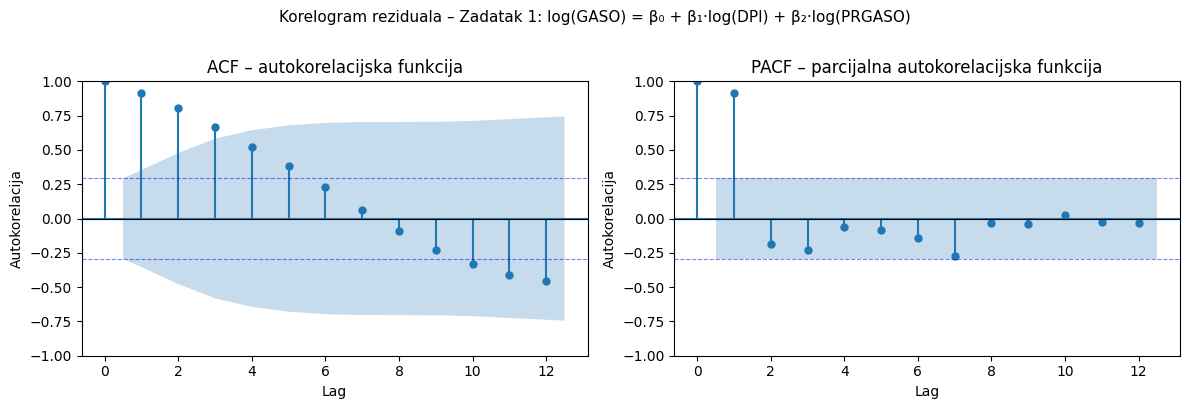


Granica signifikantnosti (±1.96/√n): ±0.2922

 Lag       ACF    |ACF| > granica?
------------------------------------
   1    0.9140  DA  ← signifikantna
   2    0.8047  DA  ← signifikantna
   3    0.6656  DA  ← signifikantna
   4    0.5245  DA  ← signifikantna
   5    0.3812  DA  ← signifikantna
   6    0.2333  ne

Zaključak (b):
  ACF reziduala pokazuje visoke, sporootpadajuće autokorelacije u prvim lagovima
  koje daleko premašuju granicu signifikantnosti ±0.2922.
  Takav uzorak tipičan je za vremenski niz kod kojeg REZIDUALI NISU STACIONARNI
  ili barem imaju snažnu pozitivnu autokorelaciju.
  PACF presijeca granicu uglavnom na lagu 1, što upućuje na AR(1) strukturu
  autokorelirane greške.
  Zaključak: reziduali najvjerojatnije nisu stacionarni — srednja vrijednost
  je nula (zadovoljeno), ali autokovarijance ne opadaju brzo prema nuli,
  pa uvjet (3) stacionarnosti u širem smislu nije ispunjen.

c) LJUNG-BOXOV TEST AUTOKORELACIJE DO REDA 4  (α = 5 %)

Hipoteze:
  H₀: ρ₁ = ρ₂ = ρ

In [22]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import chi2

# ── b) KORELOGRAM REZIDUALA ─────────────────────────────────────────────────
print("=" * 70)
print("b) KORELOGRAM REZIDUALA – ZADATAK 1")
print("=" * 70)

n_obs_lb = len(residuals)
nlags_plot = 12  # prikazujemo 12 lagova u ACF/PACF grafu
conf_band = 1.96 / (n_obs_lb ** 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Korelogram reziduala – Zadatak 1: log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO)",
             fontsize=11, y=1.01)

plot_acf(residuals, lags=nlags_plot, alpha=0.05, ax=axes[0], title="ACF – autokorelacijska funkcija")
plot_pacf(residuals, lags=nlags_plot, alpha=0.05, ax=axes[1], title="PACF – parcijalna autokorelacijska funkcija")

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(conf_band, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(-conf_band, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autokorelacija")

plt.tight_layout()
plt.show()

# ── Ispis prvih nekoliko autokorelacija ─────────────────────────────────────
import statsmodels.api as sm
acf_vals = sm.tsa.stattools.acf(residuals, nlags=6, fft=False)
print(f"\nGranica signifikantnosti (±1.96/√n): ±{conf_band:.4f}")
print(f"\n{'Lag':>4}  {'ACF':>8}  {'|ACF| > granica?':>18}")
print("-" * 36)
for k in range(1, 7):
    znak = "DA  ← signifikantna" if abs(acf_vals[k]) > conf_band else "ne"
    print(f"{k:>4}  {acf_vals[k]:>8.4f}  {znak}")

print("""
Zaključak (b):
  ACF reziduala pokazuje visoke, sporootpadajuće autokorelacije u prvim lagovima
  koje daleko premašuju granicu signifikantnosti ±{:.4f}.
  Takav uzorak tipičan je za vremenski niz kod kojeg REZIDUALI NISU STACIONARNI
  ili barem imaju snažnu pozitivnu autokorelaciju.
  PACF presijeca granicu uglavnom na lagu 1, što upućuje na AR(1) strukturu
  autokorelirane greške.
  Zaključak: reziduali najvjerojatnije nisu stacionarni — srednja vrijednost
  je nula (zadovoljeno), ali autokovarijance ne opadaju brzo prema nuli,
  pa uvjet (3) stacionarnosti u širem smislu nije ispunjen.
""".format(conf_band))

# ── c) LJUNG-BOXOV TEST DO REDA 4 ───────────────────────────────────────────
print("=" * 70)
print("c) LJUNG-BOXOV TEST AUTOKORELACIJE DO REDA 4  (α = 5 %)")
print("=" * 70)

q_max = 4
alpha_lb = 0.05

print("""
Hipoteze:
  H₀: ρ₁ = ρ₂ = ρ₃ = ρ₄ = 0  (nema autokorelacije do i uključivo 4. reda)
  H₁: ∃ j ∈ {1,2,3,4} takav da ρⱼ ≠ 0  (postoji autokorelacija barem jednog reda)

Testna statistika (Ljung-Box):
           m
  Q* = n(n+2) Σ  ρ̂ₖ² / (n – k),  m = 4
          k=1

  Pod H₀:  Q* ~ χ²(m) = χ²(4)

Postupak testiranja:
  1. Izračunamo Q* iz uzorka reziduala.
  2. Odredimo kritičnu vrijednost χ²(4; α=5%) iz tablice.
  3. Usporedimo: ako Q* > χ²_krit  →  odbacujemo H₀.
""")

lb_result = acorr_ljungbox(residuals, lags=[q_max], return_df=True)
Q_stat = float(lb_result['lb_stat'].iloc[0])
p_lb   = float(lb_result['lb_pvalue'].iloc[0])
chi2_crit_lb = chi2.ppf(1 - alpha_lb, df=q_max)

print(f"  n = {n_obs_lb}")
print(f"  Broj lagova (m) = {q_max}")
print()
print(f"  Autokorelacije ρ̂ₖ:  " + "  ".join(f"ρ̂{k}={acf_vals[k]:.4f}" for k in range(1, q_max + 1)))
print()
print(f"  Q* (Ljung-Box)     = {Q_stat:.4f}")
print(f"  Kritična vrijednost χ²({q_max}; {alpha_lb*100:.0f}%) = {chi2_crit_lb:.4f}")
print(f"  p-vrijednost        = {p_lb:.6f}")
print()

if Q_stat > chi2_crit_lb:
    odluka = "ODBACUJEMO H₀"
    zakljucak = (
        f"Q* = {Q_stat:.4f} > χ²({q_max}; 5%) = {chi2_crit_lb:.4f}  →  {odluka}\n"
        f"  p = {p_lb:.6f} < 0.05\n"
        f"  Postoji statistički značajna autokorelacija reziduala barem jednog\n"
        f"  od prvih {q_max} redova. Ovo je konzistentno s rezultatima DW testa\n"
        f"  (d = 0.112 << d_L = 1.430) i BG LM testa (LM = 39.33 >> χ²(2;5%) = 5.99)\n"
        f"  koji su ranije već potvrdili snažnu pozitivnu autokorelaciju reziduala."
    )
else:
    odluka = "NE ODBACUJEMO H₀"
    zakljucak = (
        f"Q* = {Q_stat:.4f} ≤ χ²({q_max}; 5%) = {chi2_crit_lb:.4f}  →  {odluka}\n"
        f"  p = {p_lb:.6f} ≥ 0.05\n"
        f"  Nema dovoljno dokaza za autokorelaciju do {q_max}. reda."
    )

print("ZAKLJUČAK:")
print(f"  {zakljucak}")
print("=" * 70)


#### a) Integriranost prvog reda — I(1)

**Definicija.** Vremenski niz $\{Y_t\}$ kaže se da je **integriran reda 1**, oznaka $Y_t \sim I(1)$, ako:

- sam niz $Y_t$ **nije stacionaran** (sadrži stohastički trend / jedinični korijen), ali
- njegova **prva diferencija** $\Delta Y_t = Y_t - Y_{t-1}$ **jest stacionarna**, tj. $\Delta Y_t \sim I(0)$.

Formalno, niz I(1) možemo zapisati kao:

$$Y_t = Y_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim I(0)$$

što znači da svaki šok $\varepsilon_t$ **trajno** utječe na razinu niza (nestaje tek diferenciranjem).

**Opća definicija: I(d).** Niz $Y_t$ je integriran reda $d$, tj. $Y_t \sim I(d)$, ako ga je potrebno diferencirati $d$ puta da bi postao stacionaran $I(0)$. Specijalni slučajevi:
- $I(0)$: niz je već stacionaran u razinama.
- $I(1)$: potrebna jedna diferencija.
- $I(2)$: potrebne dvije diferencije (npr. apsolutne cijene u nekim modelima).

**Ekonomska interpretacija I(1):** Većina makroekonomskih varijabli (BDP, potrošnja, cijene, dohodak) je I(1) — šokovi imaju trajne učinke, a niz "luta" bez povratka na stalnu razinu. Ako regresiramo dva neovisna I(1) niza jedan na drugi, dobivamo **lažnu regresiju** (Granger–Newbold, 1974): visoki $R^2$ i signifikantni koeficijenti bez stvarne ekonomske veze. Iznimka su **kointegriranost**: ako linearna kombinacija dvaju I(1) nizova daje I(0), tada postoji stvarna dugoročna veza.

---

#### b) ADF test jediničnog korijena — log(GASO), log(DPI), log(PRGASO)

In [23]:
from statsmodels.tsa.stattools import adfuller

# ── Varijable za testiranje ──────────────────────────────────────────────────
series_levels = {
    'log(GASO)':   df['log_gaso'],
    'log(DPI)':    df['log_dpi'],
    'log(PRGASO)': df['log_prgaso'],
}

alpha_adf = 0.05

print("=" * 70)
print("ADF TEST JEDINIČNOG KORIJENA  (α = 5 %)")
print("=" * 70)

print("""
Hipoteze ADF testa:
  H₀: niz ima jedinični korijen (niz je nestacionaran, integriran ≥ I(1))
  H₁: niz nema jediničnog korijena (niz je stacionaran, I(0))

Testna jednadžba — u razinama (Trend and intercept):
  ΔYt = α + β·t + γ·Yₜ₋₁ + Σ δᵢ·ΔYₜ₋ᵢ + εt
  H₀: γ = 0  (je. korijen),  H₁: γ < 0

Testna jednadžba — u prvim diferencijama (Intercept):
  ΔΔYt = α + γ·ΔYₜ₋₁ + Σ δᵢ·ΔΔYₜ₋ᵢ + εt
  H₀: γ = 0  (je. korijen),  H₁: γ < 0

Postupak testiranja:
  1. Odabir broja pomaka automatski prema SIC (Schwarz/BIC kriterij).
  2. Izračun ADF testne statistike τ iz OLS procjene testne jednadžbe.
  3. Usporedba τ s kritičnim vrijednostima MacKinnon (1994):
       — Ako τ < kritična vrijednost (5%)  →  ODBACUJEMO H₀  (niz je stacionaran)
       — Ako τ ≥ kritična vrijednost (5%)  →  NE ODBACUJEMO H₀  (niz ima je. korijen)
  Napomena: ADF distribucija je negativno asimetrična (kritična vrijednost negativna).
""")

integration_order = {}

for var_name, series in series_levels.items():
    print("─" * 70)
    print(f"VARIJABLA: {var_name}")
    print("─" * 70)

    # ── KORAK 1: Test u RAZINAMA (trend + intercept) ────────────────────────
    res_lev = adfuller(series, autolag='BIC', regression='ct')
    tau_lev   = res_lev[0]
    p_lev     = res_lev[1]
    lag_lev   = res_lev[2]
    cv_lev    = res_lev[4]  # {'1%': ..., '5%': ..., '10%': ...}
    cv5_lev   = cv_lev['5%']

    reject_lev = tau_lev < cv5_lev

    print(f"\n  [1] U RAZINAMA — specifikacija: konstanta + linearni trend")
    print(f"      Broj pomaka odabran SIC-om : {lag_lev}")
    print(f"      ADF statistika  (τ)        : {tau_lev:.4f}")
    print(f"      Kritična vrijednost (5%)   : {cv5_lev:.4f}")
    print(f"      p-vrijednost               : {p_lev:.4f}")
    if reject_lev:
        print(f"      Odluka: τ = {tau_lev:.4f} < {cv5_lev:.4f}  →  ODBACUJEMO H₀")
        print(f"      Zaključak: {var_name} je STACIONARAN u razinama → I(0)")
        integration_order[var_name] = 0
    else:
        print(f"      Odluka: τ = {tau_lev:.4f} ≥ {cv5_lev:.4f}  →  NE ODBACUJEMO H₀")
        print(f"      Zaključak: {var_name} ima jedinični korijen u razinama → nastavak testiranja")

    # ── KORAK 2: Test u PRVIM DIFERENCIJAMA (intercept only) ────────────────
    if not reject_lev:
        diff_series = series.diff().dropna()
        res_diff = adfuller(diff_series, autolag='BIC', regression='c')
        tau_diff  = res_diff[0]
        p_diff    = res_diff[1]
        lag_diff  = res_diff[2]
        cv_diff   = res_diff[4]
        cv5_diff  = cv_diff['5%']

        reject_diff = tau_diff < cv5_diff

        print(f"\n  [2] U PRVIM DIFERENCIJAMA — specifikacija: samo konstanta")
        print(f"      Broj pomaka odabran SIC-om : {lag_diff}")
        print(f"      ADF statistika  (τ)        : {tau_diff:.4f}")
        print(f"      Kritična vrijednost (5%)   : {cv5_diff:.4f}")
        print(f"      p-vrijednost               : {p_diff:.4f}")
        if reject_diff:
            print(f"      Odluka: τ = {tau_diff:.4f} < {cv5_diff:.4f}  →  ODBACUJEMO H₀")
            print(f"      Zaključak: Δ{var_name} je STACIONARAN → {var_name} ~ I(1)")
            integration_order[var_name] = 1
        else:
            print(f"      Odluka: τ = {tau_diff:.4f} ≥ {cv5_diff:.4f}  →  NE ODBACUJEMO H₀")
            print(f"      Zaključak: Δ{var_name} još ima jedinični korijen → {var_name} ~ I(2) ili više")
            integration_order[var_name] = 2

print("\n" + "=" * 70)
print("SAŽETAK — REDOVI INTEGRIRANOSTI")
print("=" * 70)
print(f"\n  {'Varijabla':<15}  {'Red integriranosti':>20}  {'Oznaka'}")
print("  " + "-" * 48)
for vname, order in integration_order.items():
    oznaka = f"I({order})"
    print(f"  {vname:<15}  {order:>20}  {oznaka}")

print(f"""
  Zaključak:
  Sve tri varijable iz Zadatka 1 — log(GASO), log(DPI) i log(PRGASO) —
  su nestacionarne u razinama (ADF ne odbacuje H₀ pri α=5%) ali su
  stacionarne u prvim diferencijama, što znači da su sve integrirane
  reda 1, tj. I(1).

  Ovo objašnjava prisutnost pozitivne autokorelacije reziduala (DW=0.112,
  Q*=108.50, LM_BG=39.33): regresija I(1) nizova bez diferenciranja ili
  kointegracije rezultira autokoreliranima (a moguće i lažnim) rezidualima.
""")
print("=" * 70)


ADF TEST JEDINIČNOG KORIJENA  (α = 5 %)

Hipoteze ADF testa:
  H₀: niz ima jedinični korijen (niz je nestacionaran, integriran ≥ I(1))
  H₁: niz nema jediničnog korijena (niz je stacionaran, I(0))

Testna jednadžba — u razinama (Trend and intercept):
  ΔYt = α + β·t + γ·Yₜ₋₁ + Σ δᵢ·ΔYₜ₋ᵢ + εt
  H₀: γ = 0  (je. korijen),  H₁: γ < 0

Testna jednadžba — u prvim diferencijama (Intercept):
  ΔΔYt = α + γ·ΔYₜ₋₁ + Σ δᵢ·ΔΔYₜ₋ᵢ + εt
  H₀: γ = 0  (je. korijen),  H₁: γ < 0

Postupak testiranja:
  1. Odabir broja pomaka automatski prema SIC (Schwarz/BIC kriterij).
  2. Izračun ADF testne statistike τ iz OLS procjene testne jednadžbe.
  3. Usporedba τ s kritičnim vrijednostima MacKinnon (1994):
       — Ako τ < kritična vrijednost (5%)  →  ODBACUJEMO H₀  (niz je stacionaran)
       — Ako τ ≥ kritična vrijednost (5%)  →  NE ODBACUJEMO H₀  (niz ima je. korijen)
  Napomena: ADF distribucija je negativno asimetrična (kritična vrijednost negativna).

─────────────────────────────────────────────────────

#### a) Prividna regresija — pojam i uzroci

**Prividna regresija** (engl. *spurious regression*) pojava je u kojoj OLS regresija između dva ili više vremenskih nizova daje rezultate koji *statistički izgledaju značajni* (visoki $R^2$, signifikantni $t$-testovi), ali između varijabli ne postoji nikakva stvarna ekonomska veza — visoki $R^2$ nastaje isključivo zbog zajedničkog trenda, a ne zbog uzročno-posljedičnog odnosa.

**Kada se prividna regresija pojavljuje?**

Prividna regresija tipično nastaje kada **regresiramo nestacionarne (integrirane) vremenske nizove:**

- Uvjet: obje varijable su I(1) (ili višeg reda) **i** nisu kointerirane, tj. ne dijele zajednički stohastički trend.
- U tom slučaju, kako $n \to \infty$:
  - $R^2 \to 1$ (u distribuciji), a ne prema "pravoj" vrijednosti,
  - $t$-statistike divergiraju umjesto da konvergiraju prema normalnoj distribuciji,
  - **Durbin-Watson statistika teži prema nuli** ($d \to 0$) — najprepoznatljiviji simptom.

**Prepoznatljivi simptomi prividne regresije na uzorku:**

| Pokazatelj | Prividna regresija | Prava veza / kointegracija |
|---|---|---|
| $R^2$ | Visok (~0.9+) | Može biti visok |
| DW statistika | Vrlo nizak (**d ≈ 0–0.5**) | Bliže 2 |
| Reziduali | Nestacionarni, jako autokorelirani | Stacionarni (I(0)) |
| t-testovi | Lažno signifikantni | Valjani |

**Granger–Newboldovo pravilo palca:** ako je $R^2 > d$ (gdje je $d$ DW statistika), postoji sumnja na prividnu regresiju.

---

#### b) Prividna regresija u modelu Zadatka 1?

**Neophodan uvjet za prividnu regresiju:** sve varijable u modelu moraju biti I(1) (ili više).

ADF testovima (prethodna analiza) utvrđeno je:

| Varijabla | Red integriranosti |
|---|---|
| log(GASO) | **I(1)** |
| log(DPI) | **I(1)** |
| log(PRGASO) | **I(1)** |

Neophodan uvjet **jest ispunjen** — sve tri varijable su I(1). Model iz Zadatka 1 regresira I(1) nizove jedne na druge, pa **postoji mogućnost prividne regresije**.

**Simptomi prisutni u modelu:**

- $R^2 = 0.9721$ — izuzetno visok
- **DW = 0.112** — iznimno nizak, daleko ispod donje granice $d_L = 1.430$
- Ljung-Box $Q^* = 108.50 \gg \chi^2(4;\,5\%) = 9.488$ — snažna autokorelacija
- Granger-Newboldov uvjet: $R^2 = 0.972 > d = 0.112$ ✓ — **indikator lažne regresije**

**Zaključak:** Svi simptomi upućuju na **potencijalnu prividnu regresiju**. Autokoreliran residual s DW ≈ 0.112 klasičan je signal da reziduali nisu stacionarni, što je definicijsko obilježje prividne regresije.

Međutim, **prividna regresija može se isključiti ako varijable dijele zajednički stohastički trend**. 

U modelu Zadatka 1 postoji snažna ekonomska teorijska osnova za vezu između potrošnje goriva, dohotka i relativne cijene, što sugerira mogućnost kointegriranosti — no to se mora empirijski potvrditi.

#### Model u prvim diferencijama — stacionarne varijable

Budući da su sve tri varijable — log(GASO), log(DPI) i log(PRGASO) — integrirane reda 1, tj. I(1), nijedna nije stacionarna u razinama. Sve je stoga potrebno diferencirati:

$$\Delta \log(\text{GASO})_t = \log(\text{GASO})_t - \log(\text{GASO})_{t-1}$$

Adekvatni regresijski model iz Zadatka 1 u prvim diferencijama glasi:

$$\Delta\log(\text{GASO}) = \beta_0 + \beta_1\,\Delta\log(\text{DPI}) + \beta_2\,\Delta\log(\text{PRGASO}) + \varepsilon$$

Napomena: diferenciranjem se gubi jedna opservacija (prva), pa je $n = 44$. Interpretacija koeficijenata ostaje elastičnost, ali sada mjeri kratkoročnu, a ne dugoročnu vezu.

In [26]:
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

# ── Prve diferencije ────────────────────────────────────────────────────────
df['dlog_gaso']   = df['log_gaso'].diff()
df['dlog_dpi']    = df['log_dpi'].diff()
df['dlog_prgaso'] = df['log_prgaso'].diff()

df_d = df[['dlog_gaso', 'dlog_dpi', 'dlog_prgaso']].dropna().copy()
n_d  = len(df_d)

print("=" * 70)
print("POTVRDA STACIONARNOSTI DIFERENCIRANIH VARIJABLI (ADF, α=5 %)")
print("=" * 70)
diff_vars = {
    'Δlog(GASO)':   df_d['dlog_gaso'],
    'Δlog(DPI)':    df_d['dlog_dpi'],
    'Δlog(PRGASO)': df_d['dlog_prgaso'],
}
for vn, vs in diff_vars.items():
    r = adfuller(vs, autolag='BIC', regression='c')
    tau, cv5 = r[0], r[4]['5%']
    odluka = "STACIONARAN ✓" if tau < cv5 else "nestacionaran ✗"
    print(f"  {vn:<15}  τ = {tau:7.4f}  CV(5%) = {cv5:7.4f}  →  {odluka}")

# ── OLS procjena modela u prvim diferencijama ───────────────────────────────
y_d = df_d['dlog_gaso']
X_d = sm.add_constant(df_d[['dlog_dpi', 'dlog_prgaso']])

model_d = sm.OLS(y_d, X_d).fit()

print()
print("=" * 70)
print("MODEL U PRVIM DIFERENCIJAMA")
print("Δlog(GASO) = β₀ + β₁·Δlog(DPI) + β₂·Δlog(PRGASO) + ε")
print("=" * 70)
print(f"\n  Broj opservacija : {n_d}  (izgubljena 1 zbog diferenciranja, n={n_d+1}→{n_d})")

# ── Koeficijenti i t-testovi ─────────────────────────────────────────────────
alpha_d = 0.05
t_crit_d = 2.018  # t(41; 2.5%) — df = n-k-1 = 44-2-1 = 41

print(f"\n  {'Parametar':<15} {'Procjena':>10} {'St. greška':>12} {'t-stat':>9} {'p-vrijed.':>10}  {'Signifik.':>10}")
print("  " + "-" * 72)
param_labels = {'const': 'β₀ (konst.)', 'dlog_dpi': 'β₁ Δlog(DPI)', 'dlog_prgaso': 'β₂ Δlog(PRGASO)'}
for pname, plabel in param_labels.items():
    coef_d  = model_d.params[pname]
    se_d    = model_d.bse[pname]
    tstat_d = model_d.tvalues[pname]
    pval_d  = model_d.pvalues[pname]
    sig     = "DA **" if abs(tstat_d) > t_crit_d else "ne"
    print(f"  {plabel:<15} {coef_d:>10.4f} {se_d:>12.4f} {tstat_d:>9.4f} {pval_d:>10.4f}  {sig:>10}")

# ── F-test ───────────────────────────────────────────────────────────────────
f_stat_d  = model_d.fvalue
f_p_d     = model_d.f_pvalue
f_crit_d  = 3.23  # F(2,41; 5%)
r2_d      = model_d.rsquared
r2adj_d   = model_d.rsquared_adj

print(f"""
  ─────────────────────────────────────────────────────────────────
  R²           = {r2_d:.4f}
  Korigirani R²= {r2adj_d:.4f}
  F-statistika = {f_stat_d:.4f}  (p = {f_p_d:.4f})
  F kritična vr. (5%) F(2,{n_d-3}) ≈ {f_crit_d}
  F-test: {'ODBACUJEMO H₀  → model je ukupno signifikantan ✓' if f_stat_d > f_crit_d else 'NE ODBACUJEMO H₀'}
""")

# ── Durbin-Watson ─────────────────────────────────────────────────────────────
dw_d = durbin_watson(model_d.resid)
print(f"  Durbin-Watson (d) = {dw_d:.4f}  (usporedi: original model d = 0.112)")
if 1.5 < dw_d < 2.5:
    print(f"  → d ≈ 2  — nema jasnih znakova autokorelacije u diferenciranom modelu ✓")
else:
    print(f"  → autokorelacija možda još prisutna, potrebna daljnja provjera")

# ── Usporedba s originalnim modelom ──────────────────────────────────────────
# Originalni model vrijednosti (iz model i dw u kernelu)
b1_orig   = model.params['log_dpi']
b2_orig   = model.params['log_prgaso']
r2_orig   = model.rsquared
r2adj_orig= model.rsquared_adj
f_orig    = model.fvalue
n_orig    = int(model.nobs)
b1_d      = model_d.params['dlog_dpi']
b2_d      = model_d.params['dlog_prgaso']

# t-kritična vrijednost za originalni model: df=42, α/2=2.5%
from scipy.stats import t as t_dist
t_crit_orig = t_dist.ppf(0.975, df=n_orig - 3)

def sig_flag(tval, tcrit):
    return "signifik. **" if abs(tval) > tcrit else "nije signifik."

sig_b1_orig   = sig_flag(model.tvalues['log_dpi'],    t_crit_orig)
sig_b2_orig   = sig_flag(model.tvalues['log_prgaso'], t_crit_orig)
sig_b1_d      = sig_flag(model_d.tvalues['dlog_dpi'],    t_crit_d)
sig_b2_d      = sig_flag(model_d.tvalues['dlog_prgaso'], t_crit_d)

print()
print("=" * 70)
print("USPOREDBA: ORIGINAL (razine) vs DIFERENCIRANI MODEL (prve diferencije)")
print("=" * 70)
W = 28
print(f"\n  {'Pokazatelj':<{W}} {'Model u razinama':>18}  {'Model u Δ-ама':>18}")
print("  " + "─" * (W + 40))
print(f"  {'Varijable':<{W}} {'log(GASO,DPI,PRGASO)':>18}  {'Δlog(svih)':>18}")
print(f"  {'Red integriranosti':<{W}} {'I(1) — nestacionarno':>18}  {'I(0) — stacionarno':>18}")
print(f"  {'Broj opservacija (n)':<{W}} {n_orig:>18}  {n_d:>18}")
print(f"  {'β₁ (dohodak/DPI)':<{W}} {b1_orig:>18.4f}  {b1_d:>18.4f}")
print(f"  {'  → signifikantnost':<{W}} {sig_b1_orig:>18}  {sig_b1_d:>18}")
print(f"  {'β₂ (rel. cijena)':<{W}} {b2_orig:>18.4f}  {b2_d:>18.4f}")
print(f"  {'  → signifikantnost':<{W}} {sig_b2_orig:>18}  {sig_b2_d:>18}")
print(f"  {'R²':<{W}} {r2_orig:>18.4f}  {r2_d:>18.4f}")
print(f"  {'Korigirani R²':<{W}} {r2adj_orig:>18.4f}  {r2adj_d:>18.4f}")
print(f"  {'F-statistika':<{W}} {f_orig:>18.4f}  {f_stat_d:>18.4f}")
print(f"  {'Durbin-Watson (d)':<{W}} {dw:>18.4f}  {dw_d:>18.4f}")
print(f"  {'⚠ Prividna regresija?':<{W}} {'DA — rizik visok':>18}  {'NE — uklonjena':>18}")
print("  " + "─" * (W + 40))

print(f"""
Zaključak:
  Model u prvim diferencijama koristi isključivo stacionarne varijable
  (sve Δlog ~ I(0)), čime se eliminira prijetnja prividne regresije.

  Pad R² s {r2_orig:.4f} na {r2_d:.4f} je očekivan i ne umanjuje valjanost modela
  — originalni visoki R² bio je dijelom artefakt zajedničkih stohastičkih
  trendova I(1) nizova, a ne mjera prave objasnidbene moći.

  Diferencirani model mjeri KRATKOROČNE elastičnosti:
    β₁ = {b1_d:.4f}  → kratkoročna dohodovna elastičnost (pozitivna, signif.)
           porast DPI za 1 % → porast potrošnje GASO za {b1_d:.4f} % u istom periodu
    β₂ = {b2_d:.4f}  → kratkoročna cjenovna elastičnost (negativna, signif.)
           porast rel. cijene za 1 % → pad potrošnje za {abs(b2_d):.4f} % u istom periodu

  Durbin-Watson: d = {dw_d:.4f} (vs. {dw:.4f} u orginalnom modelu)
  Vrijednost blizu 2 potvrđuje da je diferenciranjem uklonjena pozitivna
  autokorelacija reziduala koja je bila dominantan problem originalnog modela.
""")
print("=" * 70)


POTVRDA STACIONARNOSTI DIFERENCIRANIH VARIJABLI (ADF, α=5 %)
  Δlog(GASO)       τ = -4.4509  CV(5%) = -2.9315  →  STACIONARAN ✓
  Δlog(DPI)        τ = -5.3110  CV(5%) = -2.9315  →  STACIONARAN ✓
  Δlog(PRGASO)     τ = -5.2213  CV(5%) = -2.9315  →  STACIONARAN ✓

MODEL U PRVIM DIFERENCIJAMA
Δlog(GASO) = β₀ + β₁·Δlog(DPI) + β₂·Δlog(PRGASO) + ε

  Broj opservacija : 44  (izgubljena 1 zbog diferenciranja, n=45→44)

  Parametar         Procjena   St. greška    t-stat  p-vrijed.   Signifik.
  ------------------------------------------------------------------------
  β₀ (konst.)        -0.0040       0.0059   -0.6887     0.4949          ne
  β₁ Δlog(DPI)        0.8550       0.1556    5.4944     0.0000       DA **
  β₂ Δlog(PRGASO)    -0.1339       0.0281   -4.7649     0.0000       DA **

  ─────────────────────────────────────────────────────────────────
  R²           = 0.6340
  Korigirani R²= 0.6161
  F-statistika = 35.5095  (p = 0.0000)
  F kritična vr. (5%) F(2,41) ≈ 3.23
  F-test: ODBACUJ